This notebook is a 2D ($x,y$) extension to ```radiative-tube.ipynb```, where we solved the radiative transfer equations with ```pyFLD``` until equilibrium in 1D ($x$).

Here, we'll simply include the $y$ direction and see how the solution changes due to different boundary conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# to create a grid, we'll first create 3 1D arrays including ghost cells and pass them to the Grid constructor
# note that a 1-cell array is needed even if you don't intend to solve along that direction. pyFLD will simply
# not solve along directions with only 1 cell, but the internal code structure is always spatially 3D
xi = fld.grid.get_domain_with_ghosts(1, 2, Nx=100) * u.cm
yi = fld.grid.get_domain_with_ghosts(0, 1, Nx=50) * u.cm # now 50 instead of 1!
zi = fld.grid.get_domain_with_ghosts(0, 1, Nx=1) * u.cm
grid = fld.grid.Grid(xi, yi, zi, geometry='cartesian')

# now we create a fluid object
Gas = fld.fluids.Gas(grid=grid, name='basic')

# Next, this object needs a density and temperature. We can use the grid object to compute this.
# Again, these should be 3D arrays. For this problem we'll use constant density.
E0 = 1 * u.erg / u.cm**3
rho = 1 * u.g/u.cm**3 * np.ones(grid.shape)
tmp = fld.tools.Er_to_T(E0) * np.ones(grid.shape)

# Now set them in the Gas object.
Gas.set_density(rho)
Gas.set_temperature(tmp)

# Then, we need to set opacities. We'll set a constant value for both Rosseland and Planck
# via a function call. pyFLD expects the function to receive the fluid object:
Gas.enroll_kappaR(lambda f: 1.0 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1.0 * u.cm**2/u.g)

# Finally, call the setup() method to compute everything else internally
Gas.setup()

# to create the context for the radiative problem, we provide the list of fluids (in this case 1).
# For this problem we'll assume a constant flux limiter of 1/3 for simplicity
Box = fld.FLD.RadiativeEnvironment([Gas], verbose=False, name='box', constant_fluxlimiter=True)

In the 1D case, we could only modify the boundaries in the $x$ direction. Here, we'll start with the same exact setup as in the 1D case to show that it works.

In [3]:
# We need to tell the FLD object how to handle boundary conditions for any quantity
# For this we need to set the behavior of each side: x_beg, x_end, y_beg, y_end, z_beg, z_end.
# The currently supported options are zero-gradient ("reflective") or fixed value for E_rad.
val, ref = fld.grid.BOUNDARY_FIXEDVALUE, fld.grid.BOUNDARY_REFLECTIVE
bounds = [val, val, ref, ref, ref, ref]
vals   = [E0, 2*E0, 0, 0, 0, 0]
Box.declare_boundaries(bounds, vals)

In [4]:
# Before any solving, let's plot the Box state.

x = grid.x1[grid.act1].to_value('cm')
y = grid.x2[grid.act2].to_value('cm')

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in z

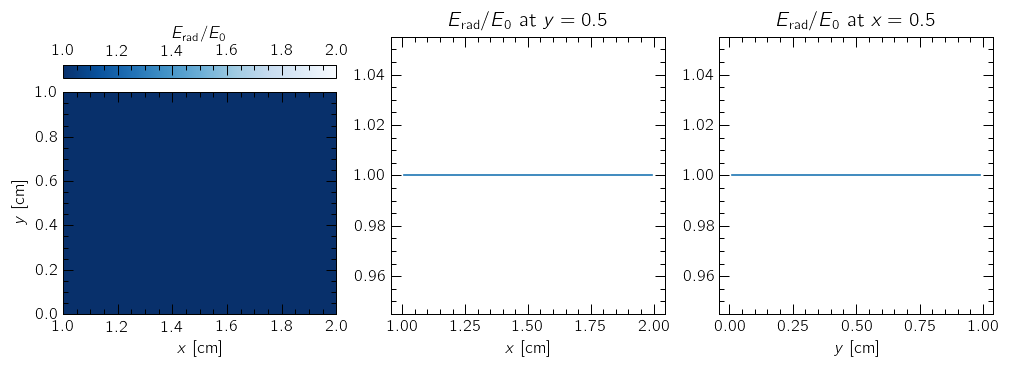

In [5]:
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[y.size//2]) # slice along x at the middle of the grid
ax[2].plot(y, Er_[:,x.size//2]) # slice along y at the middle of the grid

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ at $y=0.5$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ at $x=0.5$')

plt.show()

In [6]:
# now perform some steps with a large enough timestep...

Box.solver_settings['rtol'] = 1e-12
for _ in range(10): Box.advance(dt=1e10 * u.s)

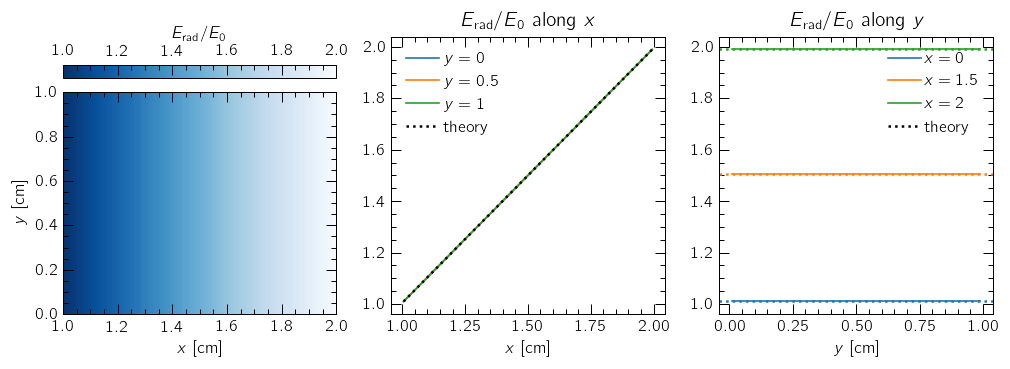

In [7]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

# overlay the analytical solution
EL = 1 * E0
ER = 2 * E0

xL = grid.x1[grid.ibeg-1].to_value('cm')
xR = grid.x1[grid.iend+1].to_value('cm')

E_theo = EL + (ER-EL) / (xR-xL) * (x-xL)

ax[1].plot(x, E_theo.to_value(E0), c='k', ls=':', lw=1.5, label='theory')
for j, index in enumerate([0, x.size//2, -1]):
    c = f'C{j}'
    ax[2].axhline( (EL + (ER-EL) / (xR-xL) * (x[index]-xL)).to_value(E0), ls=':', lw=1.5, c=c)

ax[2].plot(np.nan, np.nan, c='k', ls=':', lw=1.5, label='theory')

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()

Looks good! Now we can try a different combination of boundary conditions (we can reuse the Box object). Note that an analytical solution doesn't always exist though!

For example, we can set a high $E_\mathrm{rad}$ at $x_L$ and $x_R$, and a low $E_\mathrm{rad}$ at $y_L$ and $y_R$:

In [8]:
bounds = [val, val, val, val, ref, ref]
vals   = [2*E0, 2*E0, E0, E0, 0, 0]
Box.declare_boundaries(bounds, vals)
for _ in range(10): Box.advance(dt=1e10 * u.s)

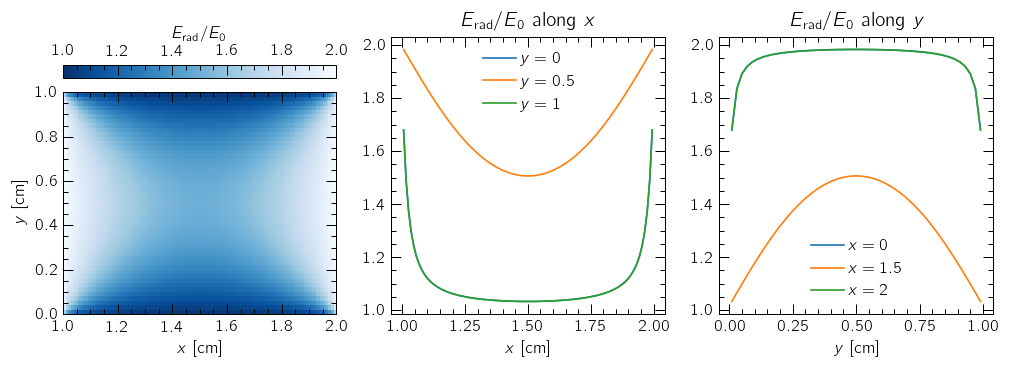

In [9]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()

Or a high-$E_\mathrm{rad}$ corner:

In [10]:
bounds = [val, val, val, val, ref, ref]
vals   = [2*E0, E0, 2*E0, E0, 0, 0]
Box.declare_boundaries(bounds, vals)
for _ in range(10): Box.advance(dt=1e10 * u.s)

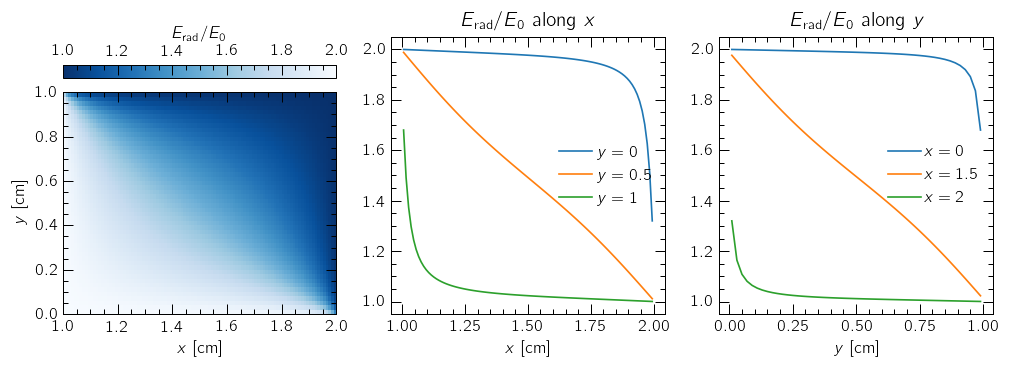

In [11]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()

And so on... Feel free to try your own combination of boundary conditions!

In [12]:
bounds = [val, ref, val, ref, ref, ref]
vals   = [2*E0, 0, E0, 0, 0, 0]
Box.declare_boundaries(bounds, vals)
for _ in range(10): Box.advance(dt=1e10 * u.s)

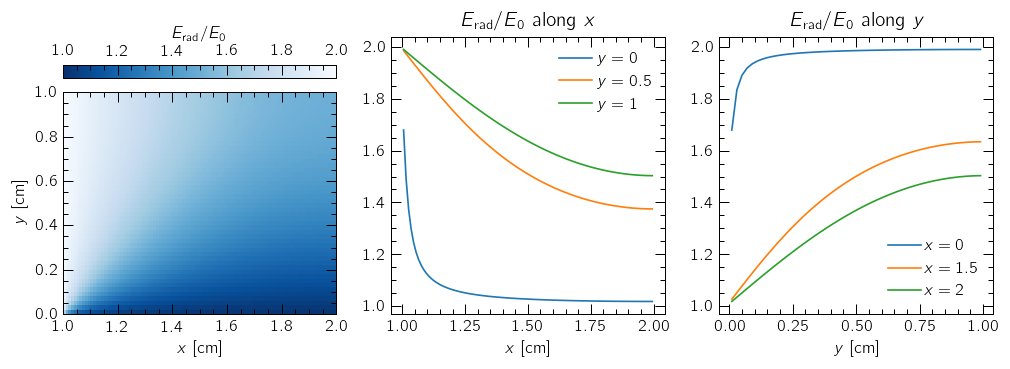

In [13]:
# ... and check the output
fig, ax = plt.subplots(ncols=3, figsize=(10, 3), dpi=120)

Er_ = fmt(Box.Er).to_value(E0)
img = ax[0].pcolormesh(x, y, Er_, vmin=1, vmax=2, cmap=plt.cm.Blues_r)
cb = plt.colorbar(img, ax=ax[0], location='top')
ax[1].plot(x, Er_[0], label=r'$y=0$') # slice along x at the first y cell
ax[1].plot(x, Er_[y.size//2], label=r'$y=0.5$') # slice along x at the central y cell
ax[1].plot(x, Er_[-1], label=r'$y=1$') # slice along x at the last y cell
ax[2].plot(y, Er_[:,0], label=r'$x=0$') # slice along y at the first x cell
ax[2].plot(y, Er_[:,x.size//2], label=r'$x=1.5$') # slice along y at the central x cell
ax[2].plot(y, Er_[:,-1], label=r'$x=2$') # slice along y at the last x cell

ax[1].legend()
ax[2].legend()

ax[0].set_xlabel(r'$x$ [cm]')
ax[1].set_xlabel(r'$x$ [cm]')
ax[2].set_xlabel(r'$y$ [cm]')
ax[0].set_ylabel(r'$y$ [cm]')
cb.set_label(r'$E_\mathrm{rad} / E_0$')
ax[1].set_title(r'$E_\mathrm{rad} / E_0$ along $x$')
ax[2].set_title(r'$E_\mathrm{rad} / E_0$ along $y$')

plt.show()